# Часть 1
Задание 1-3

Для анализа взяла три песни:
- Звезда по имени солнце, Кино
- Что такое осень, ДДТ
- Кукла колдуна, КиШ

In [1]:
song_1 = '''
Белый снег, серый лед, на растрескавшейся земле.
Одеялом лоскутным на ней - город в дорожной петле.
А над городом плывут облака, закрывая небесный свет.
А над городом - желтый дым, городу две тысячи лет,
Прожитых под светом Звезды по имени Солнце...
И две тысячи лет - война, война без особых причин.
Война - дело молодых, лекарство против морщин.
Красная, красная кровь - через час уже просто земля,
Через два на ней цветы и трава, через три она снова жива
И согрета лучами Звезды по имени Солнце...
И мы знаем, что так было всегда, что Судьбою больше любим,
Кто живет по законам другим и кому умирать молодым.
Он не помнит слово "да" и слово "нет", он не помнит ни чинов, ни имен.
И способен дотянуться до звезд, не считая, что это сон,
И упасть, опаленным Звездой по имени Солнце...
'''

song_2 = '''
Что такое осень — это небо
Плачущее небо под ногами
В лужах разлетаются птицы с облаками
Осень, я давно с тобою не был
В лужах разлетаются птицы с облаками
Осень, я давно с тобою не был
Осень, в небе жгут корабли
Осень, мне бы прочь от земли
Там, где в море тонет печаль
Осень — тёмная даль!
Что такое осень — это камни
Верность над чернеющей Невою
Осень вновь напомнила душе о самом главном
Осень, я опять лишён покоя
Осень вновь напомнила душе о самом главном
Осень, я опять лишён покоя
Осень, в небе жгут корабли
Осень, мне бы прочь от земли
Там, где в море тонет печаль
Осень — тёмная даль!
Что такое осень — это ветер
Вновь играет рваными цепями
Осень, доползём ли, долетим ли до ответа?
Что же будет с родиной и с нами?
Осень, доползём ли, долетим ли до рассвета?
Осень, что же будет завтра с нами?
Осень, в небе жгут корабли
Осень, мне бы прочь от земли
Там, где в море тонет печаль
Осень — тёмная даль!
Осень, в небе жгут корабли
Осень, мне бы прочь от земли
Там, где в море тонет печаль
Осень — тёмная даль!
Тает стаей город во мгле
Осень, что я знал о тебе?
Сколько будет рваться листва?
Осень вечно права
'''

song_3 = '''
Тёмный, мрачный коридор,
Я на цыпочках, как вор,
Пробираюсь, чуть дыша,
Чтобы не спугнуть
Тех, кто спит уже давно,
Тех, кому не всё равно,
В чью я комнату тайком
Желаю заглянуть,
Чтобы увидеть...

Как бессонница в час ночной
Меняет, нелюдимая, облик твой,
Чьих невольница ты идей?
Зачем тебе охотиться на людей?

Крестик на моей груди,
На него ты погляди,
Что в тебе способен он
Резко изменить?
Много книжек я читал,
Много фокусов видал,
Свою тайну от меня
Не пытайся скрыть!
Я это видел!

Как бессонница в час ночной
Меняет, нелюдимая, облик твой,
Чьих невольница ты идей?
Зачем тебе охотиться на людей?

Очень жаль, что ты тогда
Мне поверить не смогла,
В то, что новый твой приятель
Не такой, как все!
Ты осталась с ним вдвоём,
Не зная ничего о нём.
Что для всех опасен он,
Наплевать тебе!
И ты попала!

К настоящему колдуну,
Он загубил таких, как ты, не одну!
Словно куклой и в час ночной
Теперь он может управлять тобой!
Всё происходит, как в страшном сне.
И находиться здесь опасно мне!
'''

In [2]:
songs = [song_1, song_2, song_3]

In [3]:
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
from nltk.corpus import stopwords

stop_words= stopwords.words("russian")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/katerinkak2002/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/katerinkak2002/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/katerinkak2002/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [25]:
import re
import pymorphy2 #так как песни на русском
import numpy as np
morph = pymorphy2.MorphAnalyzer()
processed_lyrics_list = []
for text in songs:
    #Оставим только русские слова и пробелы, остальное - удалим
    reg_exp = re.compile(r'[а-яА-ЯёЁ]*\d* *', re.I)
    text = re.sub(r"\n", ' ', text)
    text = re.findall(reg_exp,text)
    text = ''.join(text).lower()
    text = re.sub('\s+', ' ', text).strip()

    # Токенизация по пробелам
    tokens = text.split()

    # Лемматизация + удаление стоп-слов
    tokens_2 = list(map(lambda x: morph.parse(x)[0].normalized.word, tokens)) #берем наиболее популярное слово
    tokens_3 = np.array(tokens_2)[np.isin(tokens_2,
                             stopwords.words("russian"), invert = True)]
    processed_lyrics_list.append(' '.join(tokens_3))
print("ПРЕДОБРАБОТАННЫЕ ТЕКСТЫ:\n", processed_lyrics_list, "\n")

ПРЕДОБРАБОТАННЫЕ ТЕКСТЫ:
 ['белый снег серый лёд растрескаться земля одеяло лоскутный город дорожный петля город плыть облако закрывать небесный свет город жёлтый дым город тысяча год прожить свет звезда имя солнце тысяча год война война особый причина война дело молодой лекарство против морщина красный красный кровь час просто земля цветок трава снова живой согреть луч звезда имя солнце знать судьба большой любим жить закон умирать молодой помнить слово слово помнить чин имя способный дотянуться звезда считать это сон упасть опалить звезда имя солнце', 'осень это небо плачущий небо нога лужа разлетаться птица облако осень давно лужа разлетаться птица облако осень давно осень небо жечь корабль осень прочь земля море тонуть печаль осень тёмный даль осень это камень верность чернеть нева осень вновь напомнить душа главный осень лишить покой осень вновь напомнить душа главный осень лишить покой осень небо жечь корабль осень прочь земля море тонуть печаль осень тёмный даль осень это ветер 

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

import time

In [6]:
times = {}
methods = ['CountVectorizer', 'TF-IDF', 'Word2Vec']


In [7]:
#count_vectorizer
start = time.time()
count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(processed_lyrics_list)
end = time.time()
times['CountVectorizer'] = end - start

In [8]:
#TF-IDF
start = time.time()
tfidf_vectorizer = TfidfVectorizer(use_idf=True)
tfidf_matrix = tfidf_vectorizer.fit_transform(processed_lyrics_list)
end = time.time()
times['TF-IDF'] = end - start

In [9]:
#Word2Vec
start = time.time()
sentences = [txt.split() for txt in processed_lyrics_list]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)
end = time.time()
times['Word2Vec'] = end - start

In [10]:
print("Замеры времени (секунды):")
for m in methods:
    print(f"{m}: {times[m]:.5f} c")

Замеры времени (секунды):
CountVectorizer: 0.00339 c
TF-IDF: 0.00757 c
Word2Vec: 0.00925 c


/Users/katerinkak2002/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


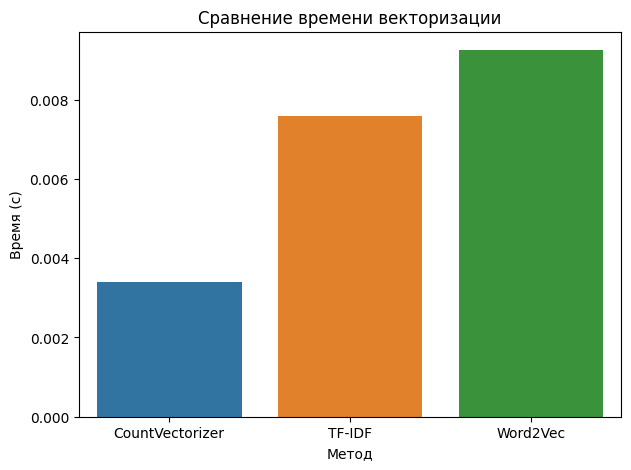

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.barplot(x=list(times.keys()), y=list(times.values()))
plt.title('Сравнение времени векторизации')
plt.xlabel('Метод')
plt.ylabel('Время (с)')
plt.show()

-> Также подтвердилось, что TF-IDF, CountVectorizer работают быстрее на небольших объемах, чем Word2Vec

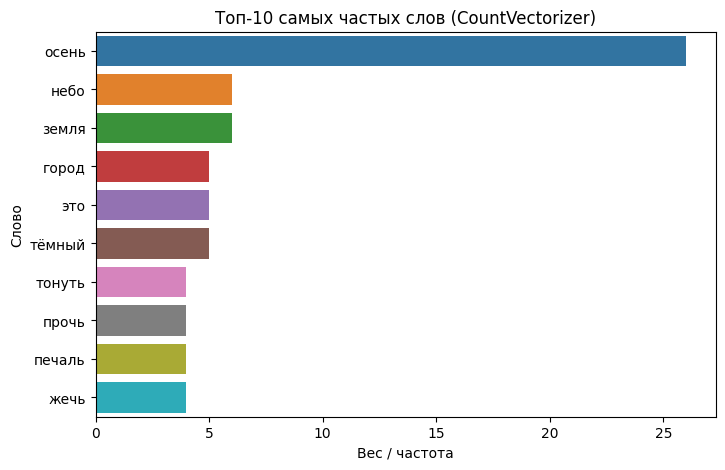

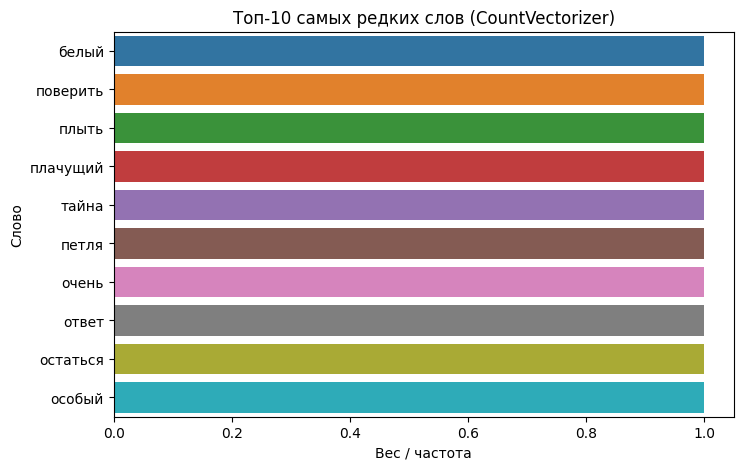

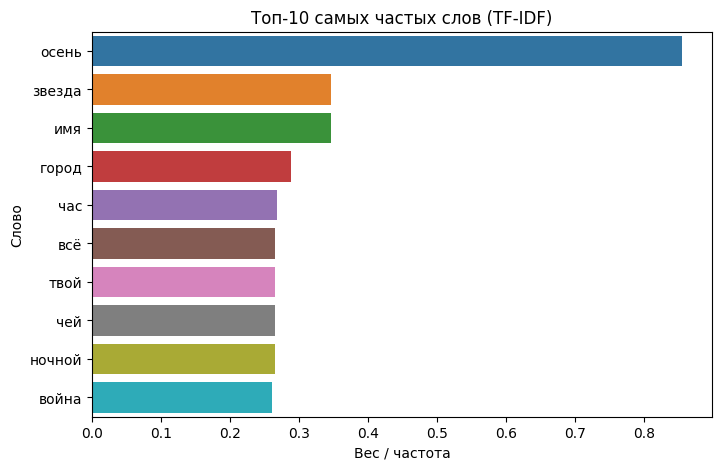

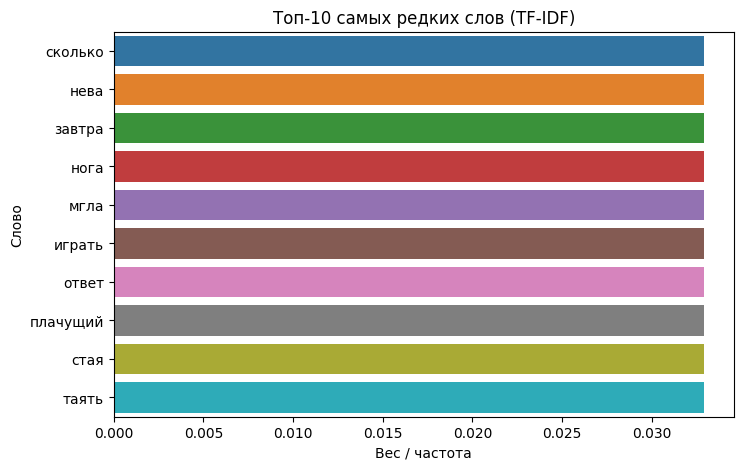

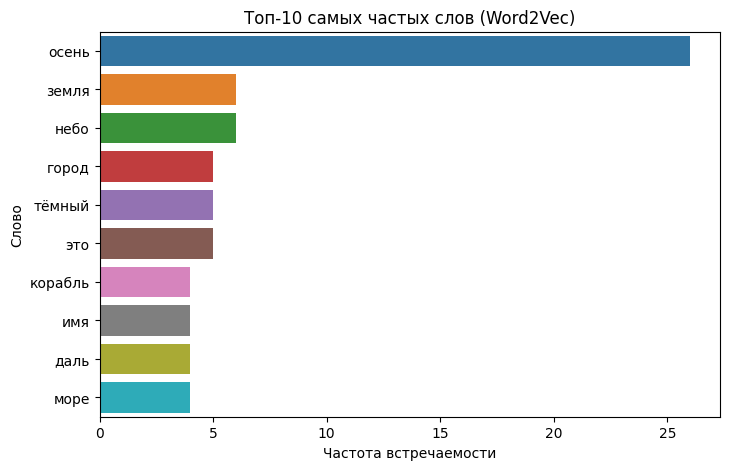

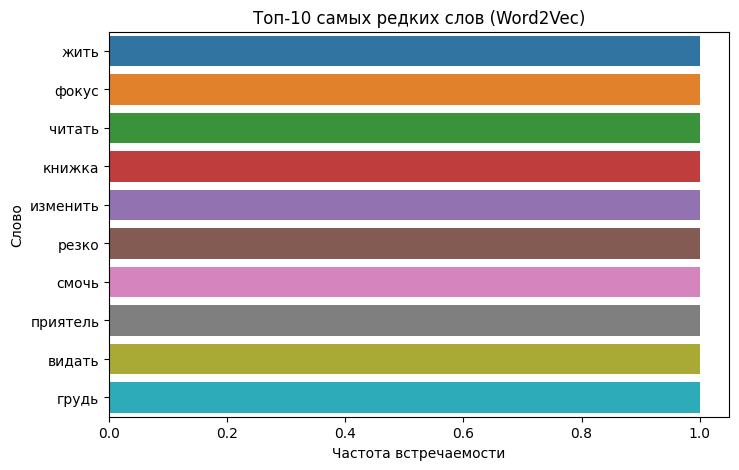

In [12]:
def plot_top_bottom_words(matrix, feature_names, method_name):
    word_counts = np.asarray(matrix.sum(axis=0)).flatten()
    df = pd.DataFrame({"word": feature_names, "count": word_counts})

    # Выбираем топ-10 самых частых слов
    df_top = df.sort_values("count", ascending=False).head(10)

    # Выбираем топ-10 самых редких слов (исключаем нулевые значения)
    df_bottom = df[df["count"] > 0].sort_values("count", ascending=True).head(10)

    # Построение графика для самых частых слов
    plt.figure(figsize=(8, 5))
    sns.barplot(y="word", x="count", data=df_top)
    plt.title(f"Топ-10 самых частых слов ({method_name})")
    plt.xlabel("Вес / частота")
    plt.ylabel("Слово")
    plt.show()

    # Построение графика для самых редких слов
    plt.figure(figsize=(8, 5))
    sns.barplot(y="word", x="count", data=df_bottom)
    plt.title(f"Топ-10 самых редких слов ({method_name})")
    plt.xlabel("Вес / частота")
    plt.ylabel("Слово")
    plt.show()


plot_top_bottom_words(count_matrix, count_vectorizer.get_feature_names_out(), "CountVectorizer")
plot_top_bottom_words(tfidf_matrix, tfidf_vectorizer.get_feature_names_out(), "TF-IDF")

# Анализ частоты слов в Word2Vec
word_counts_w2v = [(word, w2v_model.wv.get_vecattr(word, "count")) for word in w2v_model.wv.index_to_key]
df_w2v = pd.DataFrame(word_counts_w2v, columns=["word", "count"])


df_w2v_top = df_w2v.sort_values("count", ascending=False).head(10)
df_w2v_bottom = df_w2v.sort_values("count", ascending=True).head(10)

# Построение графика для самых частых слов в Word2Vec
plt.figure(figsize=(8, 5))
sns.barplot(y="word", x="count", data=df_w2v_top)
plt.title("Топ-10 самых частых слов (Word2Vec)")
plt.xlabel("Частота встречаемости")
plt.ylabel("Слово")
plt.show()

# Построение графика для самых редких слов в Word2Vec
plt.figure(figsize=(8, 5))
sns.barplot(y="word", x="count", data=df_w2v_bottom)
plt.title("Топ-10 самых редких слов (Word2Vec)")
plt.xlabel("Частота встречаемости")
plt.ylabel("Слово")
plt.show()


Топ-20 слов по суммарному TF-IDF:
осень: 0.8562
звезда: 0.3474
имя: 0.3474
город: 0.2892
час: 0.2683
всё: 0.2660
ночной: 0.2660
твой: 0.2660
чей: 0.2660
война: 0.2605
солнце: 0.2605
земля: 0.2323
небо: 0.1976
бессонница: 0.1773
идея: 0.1773
менять: 0.1773
невольница: 0.1773
нелюдимый: 0.1773
облик: 0.1773
охотиться: 0.1773


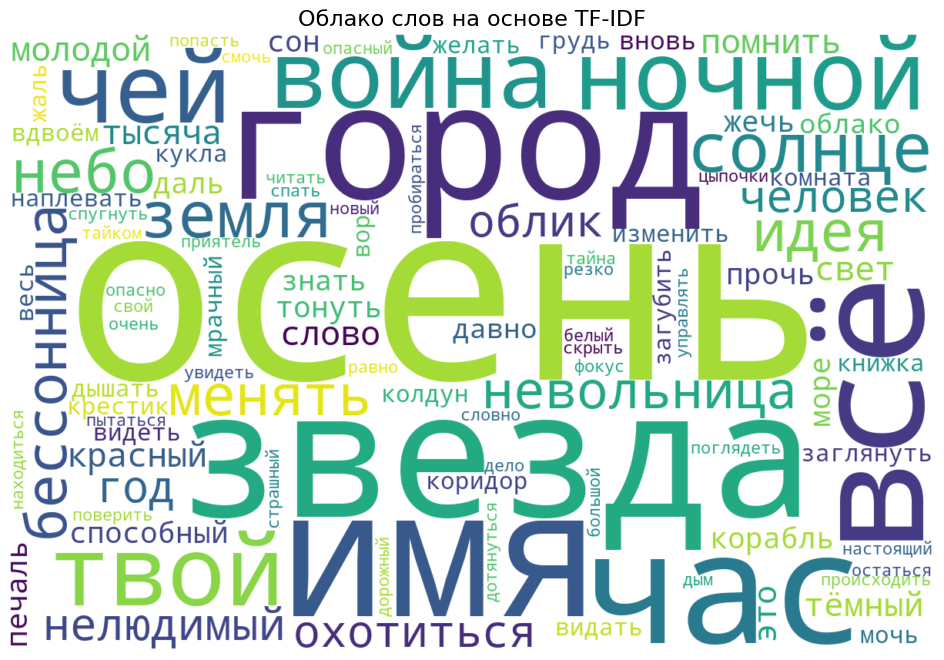

In [26]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import numpy as np

# Допустим, у вас есть список песен (уже предобработанных)

# 1. Создаем матрицу TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(processed_lyrics_list)

# 2. Получаем названия признаков (слова)
feature_names = vectorizer.get_feature_names_out()

# 3. Суммируем веса TF-IDF для каждого слова по всем песням
# Это даст нам общую "важность" слова во всем корпусе
total_weights = np.asarray(tfidf_matrix.sum(axis=0)).flatten()

# 4. Создаем словарь {слово: общий вес}
word_tfidf_dict = dict(zip(feature_names, total_weights))

# 5. Убираем возможные стоп-слова (если хотите)
# Но TfidfVectorizer уже мог их убрать, если передать параметр stop_words

# 6. Сортируем и смотрим топ-20 слов по суммарному TF-IDF
sorted_words = sorted(word_tfidf_dict.items(), key=lambda x: x[1], reverse=True)
print("Топ-20 слов по суммарному TF-IDF:")
for word, weight in sorted_words[:20]:
    print(f"{word}: {weight:.4f}")

# 7. Создаем облако слов на основе TF-IDF весов
cloud = WordCloud(
    width=1200, 
    height=800, 
    background_color='#FFFFFF',
    max_words=100  # ограничиваем количество слов для читаемости
)

# Используем наши TF-IDF веса вместо простых частот
cloud.generate_from_frequencies(word_tfidf_dict)

# 8. Отображаем
plt.figure(figsize=(12, 8))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов на основе TF-IDF', fontsize=16)
plt.show()


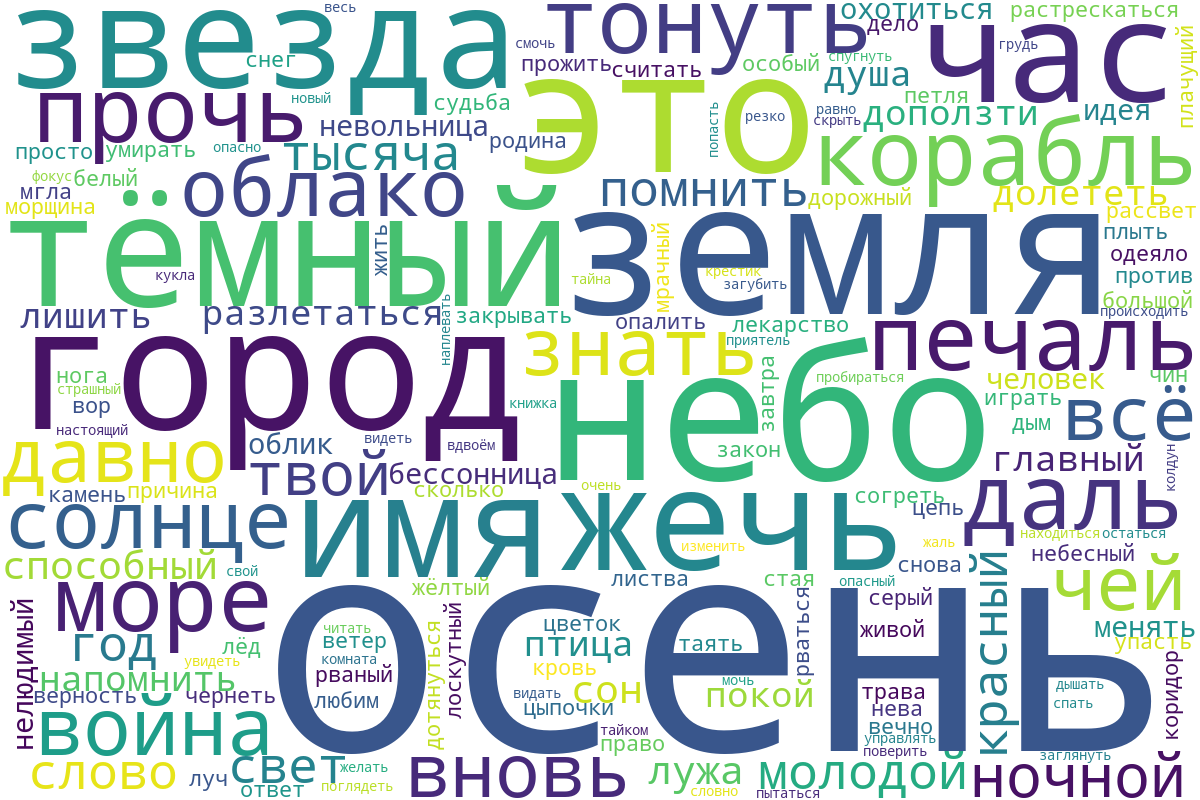

In [13]:
from wordcloud import WordCloud
from collections import Counter

#Count Vectorizer
full_text = ''
for song in processed_lyrics_list:
    full_text = full_text + song + ' '

tokens = full_text.split(" ")
word_counts = Counter(tokens)

cloud = WordCloud(width=1200, height=800, background_color = '#FFFFFF')
cloud.generate_from_frequencies(word_counts)
cloud.to_image()

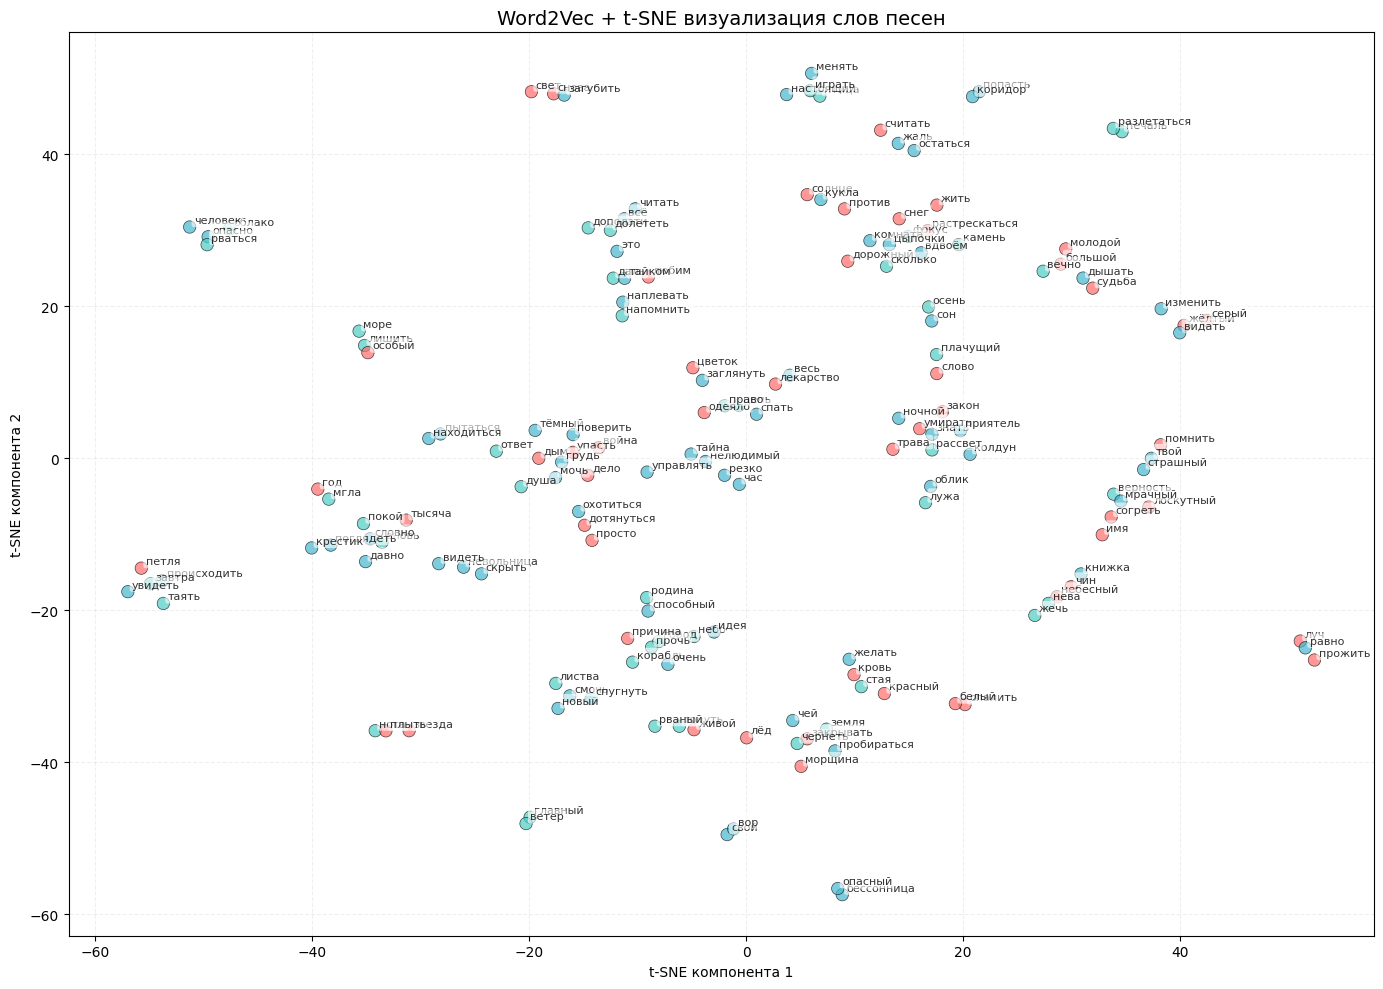

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from gensim.models import Word2Vec

# Токенизация
tokenized_songs = [song.split() for song in processed_lyrics_list]

# Обучение Word2Vec
model = Word2Vec(sentences=tokenized_songs, 
                 vector_size=50, 
                 window=2, 
                 min_count=1, 
                 workers=1, 
                 seed=42)

# Получение слов и векторов
words = list(model.wv.key_to_index.keys())
vectors = np.array([model.wv[word] for word in words])

# t-SNE
perplexity_value = min(2, len(words) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value, n_iter=1000)
vectors_2d = tsne.fit_transform(vectors)

# Цвета для песен
word_to_song = {}
for i, song_words in enumerate(tokenized_songs):
    for word in song_words:
        word_to_song[word] = i

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
song_colors = [colors[word_to_song[word]] for word in words]

# Создание DataFrame для сохранения
df = pd.DataFrame({
    'Label': words,
    'X': vectors_2d[:, 0],
    'Y': vectors_2d[:, 1]
})

# Визуализация с мелкими подписями
plt.figure(figsize=(14, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=song_colors, s=80, alpha=0.7, edgecolors='black', linewidth=0.5)

for i, word in enumerate(words):
    plt.annotate(word, 
                 xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                 xytext=(3, 3),
                 textcoords='offset points',
                 fontsize=8,  # мелкий шрифт
                 fontweight='normal',
                 alpha=0.8,
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6, edgecolor='none'))

plt.title('Word2Vec + t-SNE визуализация слов песен', fontsize=14)
plt.xlabel('t-SNE компонента 1', fontsize=10)
plt.ylabel('t-SNE компонента 2', fontsize=10)
plt.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()


plt.show()



# Часть 2
Задание 4

In [2]:
pip install transformers

In [29]:
import torch.optim as optim
import transformers

# Если transformers AdamW не доступен, создаём псевдоним
if not hasattr(transformers, 'AdamW'):
    transformers.AdamW = optim.AdamW

# Теперь можно импортировать
from transformers import AdamW

In [30]:
# импорт необходимых библиотек

import pandas as pd # табличное представление и чтение|запись csv
import numpy as np # векторы, матрицы
import random # случайный генератор
import time # измерение времени

# предобработка текста
import nltk
from nltk.corpus import stopwords # стоп-слова
from nltk.tokenize import word_tokenize # токенизация по словам

from sklearn.model_selection import train_test_split # разделение на тестовую и тренировочную выборки
import re # удаление знаков препинания через регулярное выражение

# нейронные слои
import torch
import torch.nn as nn # настройка нейросети (класс родитель)
import torch.optim as optim # оптимизация
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler # объекты настройки
import torch.nn.functional as F # функция softmax

# трансформеры, предобученные
from transformers import BertModel # класс модели BERT
from transformers import get_linear_schedule_with_warmup # оптимизатор и загрузчик
from transformers import BertTokenizer, BertForSequenceClassification # Токенизатор, классификатор

from sklearn.metrics import accuracy_score, roc_curve, auc # метрики классификации

In [31]:
import matplotlib.pyplot as plt # график, визуализация
plt.rcParams["figure.figsize"] = (10,5) # размер графиков

plt.style.use('fivethirtyeight') # стиль графиков
nltk.download('stopwords') # стоп-слова
nltk.download('punkt') # пунктуация

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/katerinkak2002/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/katerinkak2002/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
# Датасет
df_BERT = pd.read_csv('IMDB Dataset.csv')

In [33]:
df_BERT

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [34]:
df_BERT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [35]:
df_BERT.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [36]:
df_BERT.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [37]:
# рассмотрим сводную статистическую информацию о датасете
df_BERT.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [38]:
import nltk
nltk.download('punkt_tab')
# удалим знаки препинания и приведем к нижнему регистру
df_BERT['review'] = df_BERT['review'].apply(lambda x: re.sub(r'[^\w\s]', '', x.lower()))
stop_words = set(stopwords.words('english'))
# по DataFrame в цикле столбец и внести изменения
df_BERT['review'] = df_BERT['review'].apply(lambda x: ' '.join([word for word in word_tokenize(x) if word not in stop_words]))


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/katerinkak2002/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [39]:
df_BERT

,review,sentiment
0,one reviewers mentioned watching 1 oz episode ...,positive
1,wonderful little production br br filming tech...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically theres family little boy jake thinks...,negative
4,petter matteis love time money visually stunni...,positive
...,...,...
49995,thought movie right good job wasnt creative or...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,catholic taught parochial elementary schools n...,negative
49998,im going disagree previous comment side maltin...,negative


In [40]:
# замена пробелов на нижнее подчеркивание
df_BERT['review'] = df_BERT['review'].str.replace(' ', '_')

# проверим уникальные метки тональности
print(df_BERT['sentiment'].unique())

['positive' 'negative']


In [41]:
# преобразуем 'sentiment' в числовой формат
df_BERT['sentiment'] = df_BERT['sentiment'].map({'negative': 0, 'positive': 1})
df_BERT

,review,sentiment
0,one_reviewers_mentioned_watching_1_oz_episode_...,1
1,wonderful_little_production_br_br_filming_tech...,1
2,thought_wonderful_way_spend_time_hot_summer_we...,1
3,basically_theres_family_little_boy_jake_thinks...,0
4,petter_matteis_love_time_money_visually_stunni...,1
...,...,...
49995,thought_movie_right_good_job_wasnt_creative_or...,1
49996,bad_plot_bad_dialogue_bad_acting_idiotic_direc...,0
49997,catholic_taught_parochial_elementary_schools_n...,0
49998,im_going_disagree_previous_comment_side_maltin...,0


In [42]:
# разделение данных на тренировочную (70%) и тестовую (30%) выборки
x = df_BERT['review']
y = df_BERT['sentiment']

x_train, x_test, y_train, y_test = train_test_split (x, y, test_size=0.3, random_state=42)

In [43]:
# рассмотрим информацию о размерах выборок
print("Размеры тренировочной выборки:")
print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")

print("Размеры тестовой выборки:")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")

Размеры тренировочной выборки:
x_train: (35000,), y_train: (35000,)
Размеры тестовой выборки:
x_test: (15000,), y_test: (15000,)


In [20]:
# загрузка предварительно обученной модели BERT
BERT_HUGGING_MODEL = 'bert-base-uncased'

In [21]:
# загрузка предварительно обученного токенизатора BERT
tokenizer = BertTokenizer.from_pretrained(BERT_HUGGING_MODEL, do_lower_case=True) # нижний регистр

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [22]:
init_token = tokenizer.cls_token
eos_token = tokenizer.sep_token
pad_token = tokenizer.pad_token
unk_token = tokenizer.unk_token

init_token_idx = tokenizer.convert_tokens_to_ids(init_token)
eos_token_idx = tokenizer.convert_tokens_to_ids(eos_token)
pad_token_idx = tokenizer.convert_tokens_to_ids(pad_token)
unk_token_idx = tokenizer.convert_tokens_to_ids(unk_token)

print(init_token_idx, eos_token_idx, pad_token_idx, unk_token_idx)

101 102 0 100


In [23]:
tokenizer.model_max_length

512

In [24]:
tokenizer

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [25]:
# cоздаем функцию для токенизации текста
def preprocessing_for_bert(data):
    """Выполним необходимые предварительные шаги обработки данных для предварительно обученной модели BERT.
    @param    data (np.array): Массив текстов для обработки.
    @return   input_ids (torch.Tensor): Тензор идентификаторов токенов, который будет передан в модель.
    @return   attention_masks (torch.Tensor): Тензор индексов, указывающий, на какие
                  токены должна обращать внимание модель.
    """

    # создаем пустые списки для хранения результатов
    input_ids = []
    attention_masks = []

    # для каждого предложения...
    for sent in data:
        # Функция `encode_plus` выполнит следующие шаги:
        # 1. Токенизация предложения.
        # 2. Добавление токенов `[CLS]` и `[SEP]` в начало и конец.
        # 3. Усечение/дополнение предложения до максимальной длины.
        # 4. Сопоставление токенов и их идентификаторов.
        # 5. Создание маски внимания.
        # 6. Возврат словаря результатов.

        encoded_sent = tokenizer(
            sent,                           # Предобработанный текст, исходные
            add_special_tokens=True,        # Добавление `[CLS]` и `[SEP]`
            max_length=MAX_LEN,             # Максимальная длина для усечения/дополнения
            padding='max_length',            # Дополнение предложения до максимальной длины
            truncation=True,                  # Усечение длинных текстов
            return_attention_mask=True,      # Возврат маски внимания
            return_tensors=None               # Возвращаем списки, не тензоры
        )

        # добавляем результаты в соответствующие списки
        input_ids.append(encoded_sent.get('input_ids'))
        attention_masks.append(encoded_sent.get('attention_mask'))

    # преобразуем списки в тензоры
    input_ids = torch.tensor(input_ids) # обертка в тензор
    attention_masks = torch.tensor(attention_masks) # обертка в тензор

    return input_ids, attention_masks

In [26]:
# рассмотрим тренировочные и тестовые данные, формат DataFrame
print("Тренировочные данные (x_train):")
print(x_train)

print("\nТестовые данные (x_test):")
print(x_test)

Тренировочные данные (x_train):
38094    much_love_trains_couldnt_stomach_movie_premise...
40624    good_ppv_like_wrestlemania_xx_14_years_later_w...
49425    finding_right_words_everybodys_problem_vaudevi...
35734    im_really_suprised_movie_didnt_get_higher_rati...
41708    ill_start_confessing_tend_really_enjoy_action_...
                               ...                        
11284    shadow_magic_recaptures_joy_amazement_first_mo...
44732    found_movie_quite_enjoyable_fairly_entertainin...
38158    avoid_one_terrible_movie_exciting_pointless_mu...
860      production_quite_surprise_absolutely_love_obsc...
15795    decent_movie_although_little_bit_short_time_pa...
Name: review, Length: 35000, dtype: object

Тестовые данные (x_test):
33553    really_liked_summerslam_due_look_arena_curtain...
9427     many_television_shows_appeal_quite_many_differ...
199      film_quickly_gets_major_chase_scene_ever_incre...
12447    jane_austen_would_definitely_approve_onebr_br_...
39489    expe

In [27]:
# задаем максимальную длину последовательности
MAX_LEN = 128

# применим функцию 'preprocessing_for_bert' на тренировочном наборе данных и тестовом наборе данных
train_inputs, train_masks = preprocessing_for_bert(x_train)
test_inputs, test_masks = preprocessing_for_bert(x_test)
# рассморим информацию о 'train_masks' и 'train_inputs'
print("train_masks:")
print(train_masks)

print("\ntrain_inputs:")
print(train_inputs)


train_masks:
tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1]])

train_inputs:
tensor([[  101,  2172,  1035,  ..., 11737,  9148,   102],
        [  101,  2204,  1035,  ...,  6750,  1035,   102],
        [  101,  4531,  1035,  ...,  1035,  4945,   102],
        ...,
        [  101,  4468,  1035,  ...,     0,     0,     0],
        [  101,  2537,  1035,  ...,     0,     0,     0],
        [  101, 11519,  1035,  ...,  3773,  1035,   102]])


In [28]:
# создаем DataLoader для тренировочных и тестовых данных

# преобразуем объект Series или DataFrame перекодировать в массивы NumPy
if isinstance(y_train, pd.Series):
    y_train=y_train.to_numpy()

if isinstance(y_test, pd.Series):
    y_test=y_test.to_numpy()

# создаем тензоры PyTorch для меток
train_labels = torch.LongTensor(y_train)
test_labels = torch.LongTensor(y_test)

# определим размер batch size (16 или 32)
batch_size = 16

# создание 'RandomSampler' и 'DataLoader'
train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

test_data = TensorDataset(test_inputs, test_masks, test_labels)
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=batch_size)

In [29]:
# создаем классификатор на основе BERT
class BertClassifier(nn.Module):
    def __init__(self, freeze_bert=False):
        super(BertClassifier, self).__init__()

        D_in, H, D_out = 768, 50, 2

        self.bert = BertModel.from_pretrained(BERT_HUGGING_MODEL)

        self.classifier = nn.Sequential(
            nn.Linear(D_in, H),
            nn.ReLU(),
            #nn.Dropout(0.3), LSTM, GRU
            nn.Linear(H, D_out)
        )

        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids,
                            attention_mask=attention_mask)

        # смотрим CLS - начало предложения (определяем отзыв)
        last_hidden_state_cls = outputs[0][:, 0, :]

        logits = self.classifier(last_hidden_state_cls)
        return logits

In [30]:
# инициализируем модель
EPOCH_NUM = 5

def initialize_model(epochs=EPOCH_NUM):
    # создаем экземпляр BertClassifier
    bert_classifier = BertClassifier(freeze_bert=False)

    # задаем устройство (GPU T4)
    bert_classifier.to(device)

    # создаем оптимизатор
    optimizer = AdamW(bert_classifier.parameters(),
                      lr=5e-5,
                      eps=1e-8
                      )

    # делаем расчет циклов для работы
    total_steps = len(train_dataloader) * epochs

    # загрузчик, расписание (последовательность) и число циклов для обучения
    scheduler = get_linear_schedule_with_warmup(optimizer,
                                                num_warmup_steps=0,
                                                num_training_steps=total_steps)
    return bert_classifier, optimizer, scheduler

In [31]:
# определим функцию обучения модели

# функция потерь (бинарная классификация), не бинарная - заменить функцию
loss_fn = nn.CrossEntropyLoss()

def set_seed(seed_value=1):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

def train(model, train_dataloader, test_dataloader=None, epochs=EPOCH_NUM, evaluation=False):
    """

      Тренировка BertClassifier model

    """
    print("Начало тренировки...\n")
    for epoch_i in range(epochs):
        # =======================================
        #               Training
        # =======================================
        # Print the header of the result table
        print(f"{'Epoch':^7} | {'Batch':^7} | {'Train Loss':^12} | {'Test Loss':^10} | {'Test Acc':^9} | {'Elapsed':^9}")
        print("-"*70)

        # измерение времени (elapsed time of each epoch)
        t0_epoch, t0_batch = time.time(), time.time()

        # обнулить переменные
        total_loss, batch_loss, batch_counts = 0, 0, 0

        # перевод в режим тренировки
        model.train()

        # для каждого batch
        for step, batch in enumerate(train_dataloader):
            batch_counts +=1
            # загружаем каждую batch в GPU
            b_input_ids, b_attn_mask, b_labels = tuple(t.to(device) for t in batch)

            # использование нулевого градиента
            model.zero_grad()

            # добавляем в модель id и маски
            logits = model(b_input_ids, b_attn_mask)

            # считаем потери (Кросс Энтропия)
            loss = loss_fn(logits, b_labels)
            batch_loss += loss.item()
            total_loss += loss.item()

            # расчет градиентов функцией backward
            loss.backward()

            # решение проблемы "взрывных градиентов"
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # обновляем шаг для оптимизатора и расписания
            optimizer.step()
            scheduler.step()

            # печатаем значения для каждых 20 batch
            if (step % 20 == 0 and step != 0) or (step == len(train_dataloader) - 1):
                # время расчета 20 batches
                time_elapsed = time.time() - t0_batch

                # результаты
                print(f"{epoch_i + 1:^7} | {step:^7} | {batch_loss / batch_counts:^12.6f} | {'-':^10} | {'-':^9} | {time_elapsed:^9.2f}")

                # обнулим переменные
                batch_loss, batch_counts = 0, 0
                t0_batch = time.time()

        # средняя функция потерь
        avg_train_loss = total_loss / len(train_dataloader)

        print("-"*70)
        # =======================================
        #               Оценка
        # =======================================
        if evaluation == True:
            # считается точность
            test_loss, test_accuracy = evaluate(model, test_dataloader)

            # общее время, затраченное на измерение
            time_elapsed = time.time() - t0_epoch

            print(f"{epoch_i + 1:^7} | {'-':^7} | {avg_train_loss:^12.6f} | {test_loss:^10.6f} | {test_accuracy:^9.2f} | {time_elapsed:^9.2f}")
            print("-"*70)
        print("\n")

    print("Тренировка завершена!")

In [32]:
# определим функцию вычисления показателей качества модели (функцию потерь и точность)
def evaluate(model, test_dataloader):

    model.eval()

    test_accuracy = []
    test_loss = []

    for batch in test_dataloader:
        b_input_ids, b_attn_mask, b_labels = tuple(t.to(device) for t in batch)

        with torch.no_grad():
            logits = model(b_input_ids, b_attn_mask)

        loss = loss_fn(logits, b_labels)
        test_loss.append(loss.item())

        preds = torch.argmax(logits, dim=1).flatten()

        accuracy = (preds == b_labels).cpu().numpy().mean() * 100
        test_accuracy.append(accuracy)

    test_loss = np.mean(test_loss)
    test_accuracy = np.mean(test_accuracy)

    return test_loss, test_accuracy

In [33]:
# определяем устройство для модели
device = torch.device("cuda")

In [34]:
# обучение модели
set_seed(1)
bert_classifier, optimizer, scheduler = initialize_model(epochs=3)
train(bert_classifier, train_dataloader, test_dataloader, epochs=3, evaluation=True)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Начало тренировки...

 Epoch  |  Batch  |  Train Loss  | Test Loss  | Test Acc  |  Elapsed 
----------------------------------------------------------------------
   1    |   20    |   0.705288   |     -      |     -     |   7.62   
   1    |   40    |   0.698796   |     -      |     -     |   6.56   
   1    |   60    |   0.690723   |     -      |     -     |   6.62   
   1    |   80    |   0.657396   |     -      |     -     |   6.69   
   1    |   100   |   0.657411   |     -      |     -     |   6.78   
   1    |   120   |   0.524396   |     -      |     -     |   6.84   
   1    |   140   |   0.610120   |     -      |     -     |   6.93   
   1    |   160   |   0.590121   |     -      |     -     |   7.06   
   1    |   180   |   0.627351   |     -      |     -     |   7.18   
   1    |   200   |   0.546104   |     -      |     -     |   7.27   
   1    |   220   |   0.541156   |     -      |     -     |   7.38   
   1    |   240   |   0.532732   |     -      |     -     |   7.57 

In [35]:
# загрузим натренированную модель
def bert_predict(model, test_dataloader):
    model.eval()

    all_logits = []

    for batch in test_dataloader:
        b_input_ids, b_attn_mask = tuple(t.to(device) for t in batch)[:2]

        with torch.no_grad():
            logits = model(b_input_ids, b_attn_mask)
        all_logits.append(logits)

    # Сбор из каждого batch результатов в один объект
    all_logits = torch.cat(all_logits, dim=0)

    # Для вероятности принадлежности к классу
    probs = F.softmax(all_logits, dim=1).cpu().numpy()

    return probs

In [36]:
# построим график ROC-кривой для наглядной оценки качества предсказания
def evaluate_roc(probs, y_true):

    preds = probs[:, 1]
    fpr, tpr, threshold = roc_curve(y_true, preds)
    roc_auc = auc(fpr, tpr)
    print(f'AUC: {roc_auc:.4f}')

    # Get accuracy over the test set
    y_pred = np.where(preds >= 0.5, 1, 0)
    accuracy = accuracy_score(y_true, y_pred)
    print(f'Accuracy: {accuracy*100:.2f}%')

    # ROC AUC
    plt.title('Оценка ROC AUC')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

AUC: 0.9119
Accuracy: 83.11%


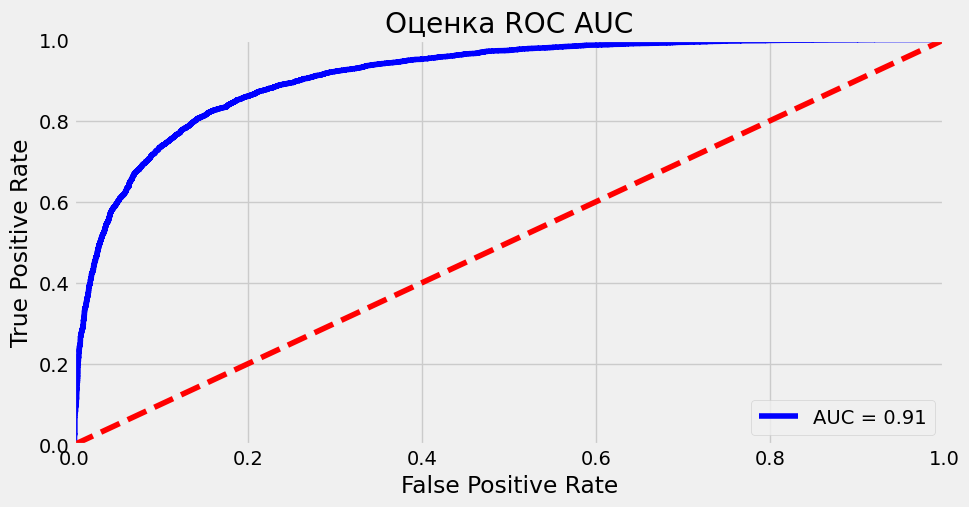

In [37]:
# вычислим предсказанные вероятности на тестовых данных
probs = bert_predict(bert_classifier, test_dataloader) # оценка занимает время

# оценим Bert classifier
evaluate_roc(probs, y_test)

In [47]:
import sklearn
from sklearn.metrics import precision_score, recall_score, f1_score
predictions = np.argmax(probs, axis=1)
# Вычисляем метрики
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Precision: 0.8353
Recall: 0.8298
F1-score: 0.8325
